# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

G = 6.67e-11
g = 9.81
M_E = 5.9e24 # earth mass
M_M = 7.3e22 # moon mass
R_E = 6.378e6 # earth radius
R_M = 1.737e6 # moon radius
d_EM = 3.8e8
m_command = 5500 # command module
v_e = 2.4e3
m_dot = 1.3e4
m_0 = 2.8e6
m_f = 7.5e5

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [8]:
def gravitational_potential(M, x_M, y_M, x, y):
    """
    Computes the gravitational potential at a point (x, y) due to a point mass M at (x_M, y_M).

    phi(r) = -G*M/r

    Parameters:
    M : primary body mass [kg]
    x_M : x-coordinate of mass [m]
    y_M : y-coordinate of mass [m]
    x : x-coordinate of reference point [m]
    y : y-coordinate of reference point [m]

    Returns:
    float : gravitational potential [m^2 s^-2]

    Raises
    ------
    TypeError  : if any input arg is not an int or float
    ValueError : if M <= 0, r_min <= 0, or calculated r is close to 0
    """
    for name, val in [("M", M), ("x_M", x_M), ("y_M", y_M),
                      ("x", x), ("y", y)]:
        if not isinstance(val, (int, float)):
            raise TypeError(f"'{name}' must be an int or float, type is {type(val).__name__}.")
    if M <= 0:
        raise ValueError(f"M must be positive, M = {M}.")
    
    r = np.sqrt((x - x_M)**2 + (y - y_M)**2)

    if np.isclose(r,0):
        raise ValueError(f"r must be greater than 0, r = {r}.")

    return -G*M/r

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

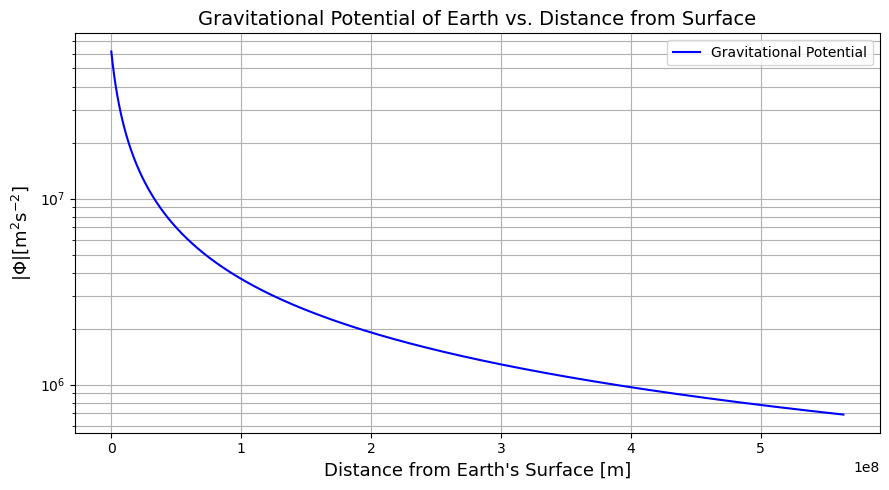

In [48]:
x_vals = np.linspace(R_E, 1.5 * d_EM, 1000)
phi_vals = np.array([gravitational_potential(M_E, 0, 0, x, 0) for x in x_vals])

x_surface = x_vals - R_E

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_surface, np.abs(phi_vals), color='blue', label='Gravitational Potential')
ax.set_yscale('log')
ax.set_xlabel('Distance from Earth\'s Surface [m]', fontsize=13)
ax.set_ylabel(r'$|\Phi|[\mathrm{m^2s^{-2}}]$', fontsize=13)
ax.set_title('Gravitational Potential of Earth vs. Distance from Surface', fontsize=14)
ax.legend()
ax.grid(True, which='both')
plt.tight_layout()
plt.show()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

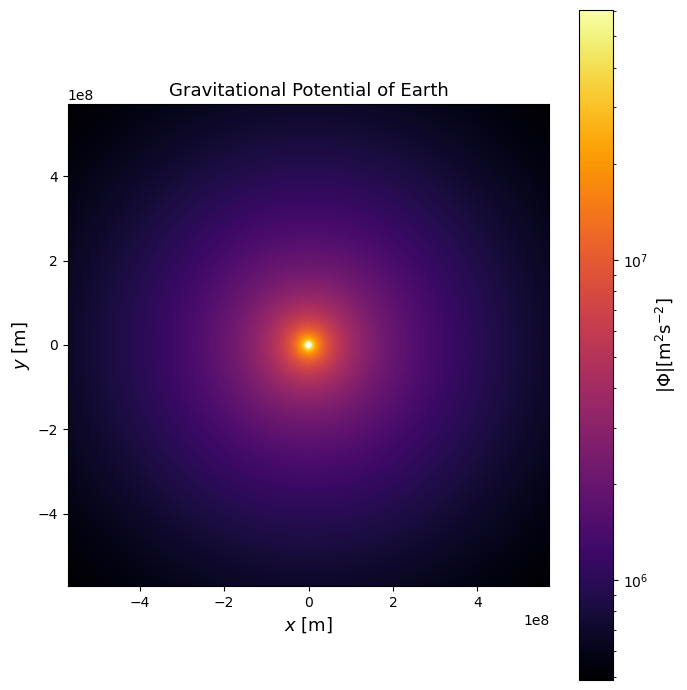

In [47]:
grid = np.linspace(-1.5*d_EM, 1.5*d_EM, 1000)
X, Y = np.meshgrid(grid, grid)
R = np.sqrt(X**2 + Y**2)
R = np.where(R < R_E, np.nan, R)
phi = np.abs(-G*M_E/R)

fig, ax = plt.subplots(figsize=(7, 7))
mesh = ax.pcolormesh(X, Y, phi, cmap='inferno', shading='auto', norm=mcolors.LogNorm(vmin=np.nanmin(phi), vmax=np.nanmax(phi))) # this is kind of a hodge-podge i cooked up with 10 minutes of documentation trowling
cbar = fig.colorbar(mesh)
cbar.set_label(r'$|\Phi|[\mathrm{m^2s^{-2}}]$', fontsize=13)
ax.set_aspect('equal')
ax.set_xlabel(r'$x$ [m]', fontsize=13)
ax.set_ylabel(r'$y$ [m]', fontsize=13)
ax.set_title("Gravitational Potential of Earth", fontsize=13)
plt.tight_layout()
plt.show()

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

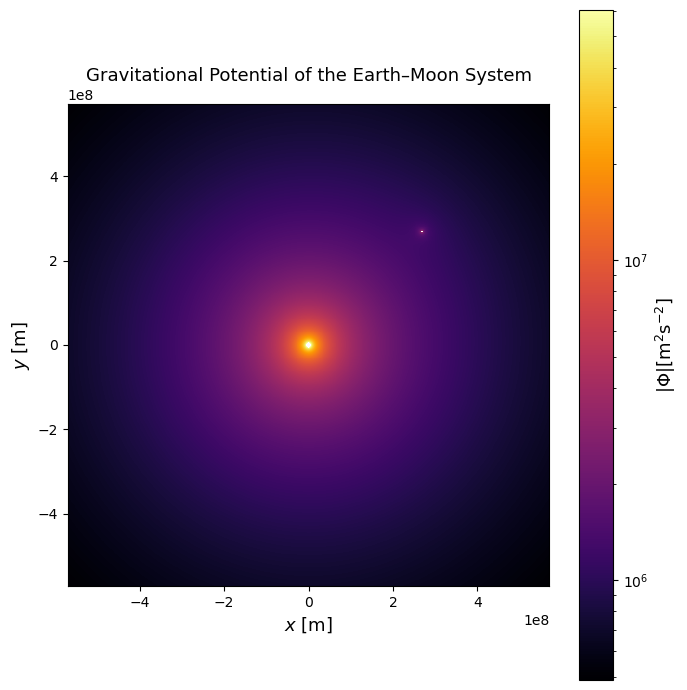

In [49]:
x_E, y_E = 0.0, 0.0
x_M = d_EM/np.sqrt(2)
y_M = d_EM/np.sqrt(2)
grid = np.linspace(-1.5 * d_EM, 1.5 * d_EM, 1000)
X, Y = np.meshgrid(grid, grid)
R_earth = np.sqrt((X - x_E)**2 + (Y - y_E)**2)
R_moon  = np.sqrt((X - x_M)**2 + (Y - y_M)**2)
R_earth = np.where(R_earth < R_E, np.nan, R_earth)
R_moon  = np.where(R_moon  < R_M, np.nan, R_moon)
phi_tot = np.abs(-G*M_E/R_earth + -G*M_M/R_moon)

fig, ax = plt.subplots(figsize=(7, 7))
mesh = ax.pcolormesh(X, Y, phi_tot, cmap='inferno', shading='auto', norm=mcolors.LogNorm(vmin=np.nanmin(phi), vmax=np.nanmax(phi)))
cbar = fig.colorbar(mesh)
cbar.set_label(r'$|\Phi|[\mathrm{m^2s^{-2}}]$', fontsize=13)
ax.set_aspect('equal')
ax.set_xlabel(r'$x$ [m]', fontsize=13)
ax.set_ylabel(r'$y$ [m]', fontsize=13)
ax.set_title('Gravitational Potential of the Earth–Moon System', fontsize=13)
plt.tight_layout()
plt.show()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

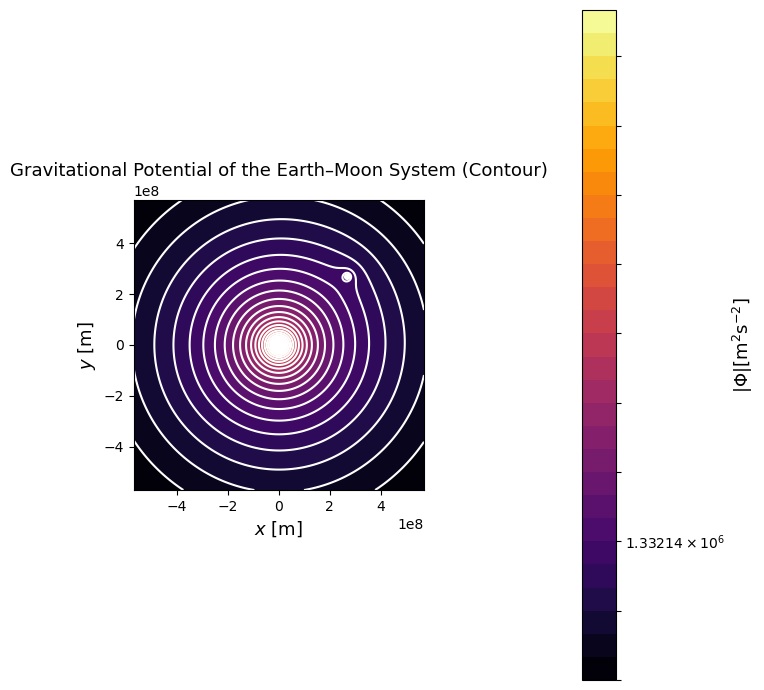

In [62]:
log_levels = np.logspace(np.log10(np.nanmin(phi_tot)), np.log10(np.nanmax(phi_tot)), 30)
fig, ax = plt.subplots(figsize=(7, 7))
log_norm = mcolors.LogNorm(vmin=np.nanmin(phi), vmax=np.nanmax(phi))
contour_fill = ax.contourf(X, Y, phi_tot, levels=log_levels, norm=log_norm, cmap='inferno')
ax.contour(X, Y, phi_tot, levels=log_levels, norm=log_norm, colors='white')
cbar = fig.colorbar(contour_fill, pad=0.3) # a lil padding so the cbar fits oh yeahhh
cbar.set_label(r'$|\Phi|[\mathrm{m^2s^{-2}}]$', fontsize=13)
ax.set_aspect('equal')
ax.set_xlabel(r'$x$ [m]', fontsize=13)
ax.set_ylabel(r'$y$ [m]', fontsize=13)
ax.set_title('Gravitational Potential of the Earth–Moon System (Contour)', fontsize=13)
plt.tight_layout()
plt.show()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [63]:
def gravitational_force(M1, m2, x1, y1, x2, y2):
    """
    Computes the gravitational force vector exerted on mass m2 by mass M1.
    F_21 = -G*M1*m2/|r_21|^2*r_hat_21
    where r_21 is the displacement vector from M1 to m2.
    
    Parameters:
    M1 : primary body mass [kg]
    m2 : secondary body mass [kg]
    x1 : x-coordinate of primary body [m]
    y1 : y-coordinate of primary body [m]
    x2 : x-coordinate of secondary body [m]
    y2 : y-coordinate of secondary body [m]
    
    Returns:
    (F_x, F_y) : gravitational force components on m2 [N]
    
    Raises"
    TypeError : if any input arg is not an int or float
    ValueError : if M1 <= 0, m2 <= 0, or r is close to 0
    """
    for name, val in [("M1", M1), ("m2", m2), ("x1", x1), ("y1", y1),
                      ("x2", x2), ("y2", y2)]:
        if not isinstance(val, (int, float)):
            raise TypeError(f"'{name}' must be an int or float, type is {type(val).__name__}.")
    if M1 <= 0:
        raise ValueError(f"M1 must be positive, M1 = {M1}.")
    if m2 <= 0:
        raise ValueError(f"m2 must be positive, m2 = {m2}.")

    r21_x = x2 - x1
    r21_y = y2 - y1
    r = np.sqrt(r21_x**2 + r21_y**2)

    if np.isclose(r, 0):
        raise ValueError(f"r must be greater than 0, r = {r}.")

    r_hat_x = r21_x / r
    r_hat_y = r21_y / r

    F_mag = -G * M1 * m2 / r**2
    F_x = F_mag * r_hat_x
    F_y = F_mag * r_hat_y

    return F_x, F_y

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

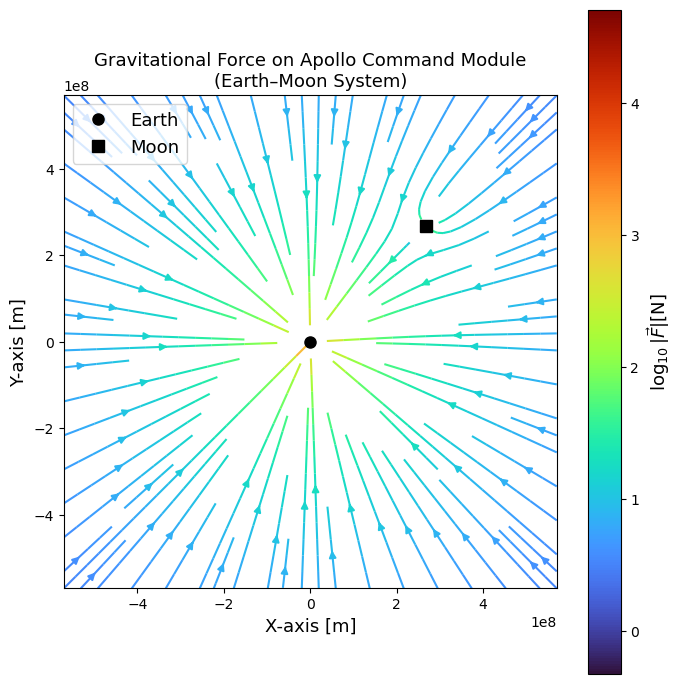

In [72]:
grid_stream = np.linspace(-1.5 * d_EM, 1.5 * d_EM, 1000)
X_s, Y_s = np.meshgrid(grid_stream, grid_stream)
R_earth_s = np.sqrt((X_s - x_E)**2 + (Y_s - y_E)**2)
R_moon_s  = np.sqrt((X_s - x_M)**2 + (Y_s - y_M)**2)
mask = (R_earth_s < R_E) | (R_moon_s < R_M) # woaaahhh

r_hat_ex = (X_s - x_E)/R_earth_s
r_hat_ey = (Y_s - y_E)/R_earth_s
r_hat_mx = (X_s - x_M)/R_moon_s
r_hat_my = (Y_s - y_M)/R_moon_s

Fx = -G*M_E*m_command/R_earth_s**2*r_hat_ex + -G*M_M*m_command/R_moon_s**2*r_hat_mx
Fy = -G*M_E*m_command/R_earth_s**2*r_hat_ey + -G*M_M*m_command/R_moon_s**2*r_hat_my
Fx = np.where(mask, np.nan, Fx)
Fy = np.where(mask, np.nan, Fy)
F_mag = np.sqrt(Fx**2 + Fy**2)

fig, ax = plt.subplots(figsize=(7, 7))
stream = ax.streamplot(X_s, Y_s, Fx, Fy, color=np.log10(F_mag), cmap='turbo') # turbo mode !!!!
cbar = fig.colorbar(stream.lines)
cbar.set_label(r'$\log_{10}|\vec{F}|[\mathrm{N}]$', fontsize=13)
ax.plot(x_E, y_E, 'ko', ms=8, label='Earth')
ax.plot(x_M, y_M, 'ks', ms=8, label='Moon')
ax.set_aspect('equal')
ax.set_xlabel('X-axis [m]', fontsize=13)
ax.set_ylabel('Y-axis [m]', fontsize=13)
ax.set_title('Gravitational Force on Apollo Command Module\n(Earth–Moon System)', fontsize=13)
ax.legend(fontsize=13, loc='upper left')
plt.tight_layout()
plt.show()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

$|\vec F|=\frac{GM_1m_2}{r^2}$<br>
$\frac{GM_{earth}m}{r^2_{earth}}=\frac{GM_{moon}m}{r^2_{moon}}$<br>
$\frac{M_{earth}}{r^2_{earth}}=\frac{M_{moon}}{r^2_{moon}}$<br>
Given $r_{moon}=d_{EM}-r_{earth}$, $\rightarrow\frac{M_{earth}}{r_{earth}^2}=\frac{M_{moon}}{(d_{EM}-r_{earth})^2}$<br>
$M_{earth}(d_{EM}-r_{earth})^2=M_{moon}r_{earth}^2$<br>
$\sqrt{M_{earth}}(d_{EM}-r_{earth})=\sqrt{M_{moon}}r_{earth}$<br>
$\sqrt{M_{earth}}d_{EM}=r_{earth}(\sqrt{M_{earth}}+\sqrt{M_{moon}})$<br>
$r_{earth}=\frac{\sqrt{M_{earth}}}{\sqrt{M_{earth}}+\sqrt{M_{moon}}}d_{EM}$
$(x,y)=(\frac{d_EM}{\sqrt 2},\frac{d_EM}{\sqrt 2}),\rightarrow \boxed{(x_{balance},y_{balance})=(\frac{r_{earth}}{\sqrt 2},\frac{r_{earth}}{\sqrt 2})}$

And your updated plot, including the balance point, goes in the cell below.

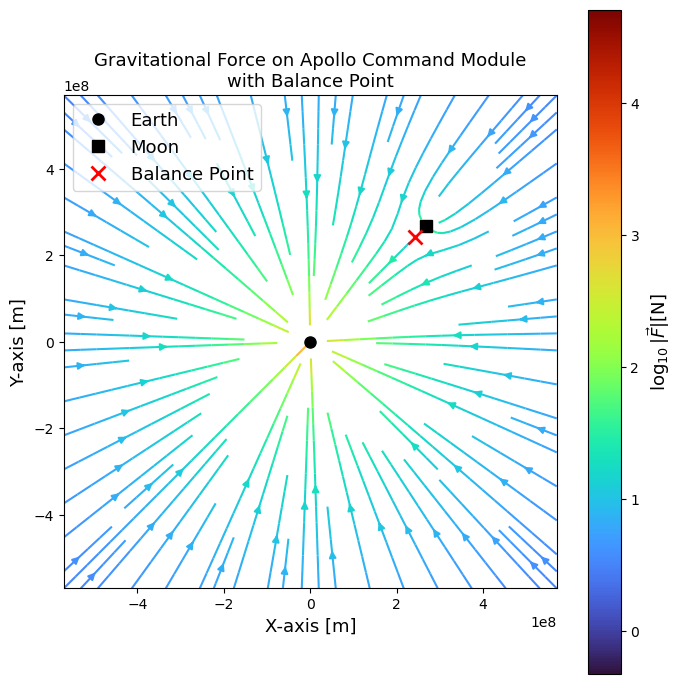

In [76]:
r_E_bp = (np.sqrt(M_E)/(np.sqrt(M_E) + np.sqrt(M_M)))*d_EM
x_bp = r_E_bp/np.sqrt(2)
y_bp = r_E_bp/np.sqrt(2)

# streamplot with balance point marked
fig, ax = plt.subplots(figsize=(7, 7))
stream = ax.streamplot(X_s, Y_s, Fx, Fy, color=np.log10(F_mag), cmap='turbo')
cbar = fig.colorbar(stream.lines)
cbar.set_label(r'$\log_{10}|\vec{F}|[\mathrm{N}]$', fontsize=13)
ax.plot(x_E, y_E, 'ko', markersize=8, label='Earth')
ax.plot(x_M, y_M, 'ks', markersize=8, label='Moon')
ax.plot(x_bp, y_bp, 'rx', markersize=10, markeredgewidth=2, label='Balance Point')
ax.set_aspect('equal')
ax.set_xlabel('X-axis [m]', fontsize=13)
ax.set_ylabel('Y-axis [m]', fontsize=13)
ax.set_title('Gravitational Force on Apollo Command Module\nwith Balance Point', fontsize=13)
ax.legend(fontsize=13, loc='upper left')
plt.tight_layout()
plt.show()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is much closer to the moon, being placed rather close to the surface of the moon. This makes sense as the field for the earth is very strong in comparison to the moon's field, meaning the balance point would need to be much further from the earth in comparison to the distance to the moon. 

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**